In [1]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ENTERPRISE HR AI PLATFORM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATH CONFIGURATION
# ============================================================

CURRENT_DIR = Path.cwd()

# Notebook is inside enterprise_hr_ai/notebooks
PROJECT_ROOT = CURRENT_DIR.parent

# Processed datasets
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

# Create folder for EDA outputs
EDA_OUTPUT_PATH = PROJECT_ROOT / "data" / "eda_outputs"

EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

print("Current Working Directory:")
print(CURRENT_DIR)

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nProcessed Data Path:")
print(PROCESSED_DATA_PATH)

print("\nProcessed Data Exists:")
print(PROCESSED_DATA_PATH.exists())

print("\nEDA Output Path:")
print(EDA_OUTPUT_PATH)

Current Working Directory:
C:\Users\Shubham\Desktop\enterprise_hr_ai\notebooks

Project Root:
C:\Users\Shubham\Desktop\enterprise_hr_ai

Processed Data Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\processed

Processed Data Exists:
True

EDA Output Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\eda_outputs


In [3]:
# ============================================================
# LOAD PROCESSED DATASETS
# ============================================================

datasets = {
    "employee_attrition": "employee_attrition_cleaned.csv",
    "performance_engagement": "performance_engagement_cleaned.csv",
    "occupational_data": "occupational_data_cleaned.csv",
    "essential_skills": "essential_skills_cleaned.csv",
    "software_skills": "software_skills_cleaned.csv"
}

processed_data = {}

for name, filename in datasets.items():

    file_path = PROCESSED_DATA_PATH / filename

    processed_data[name] = pd.read_csv(file_path)

    print(
        f"✓ Loaded {name}: "
        f"{processed_data[name].shape}"
    )

✓ Loaded employee_attrition: (1470, 35)
✓ Loaded performance_engagement: (5000, 13)
✓ Loaded occupational_data: (1016, 3)
✓ Loaded essential_skills: (18200, 15)
✓ Loaded software_skills: (31821, 7)


In [4]:
# ============================================================
# CREATE EASY DATASET VARIABLES
# ============================================================

employee_df = processed_data["employee_attrition"]

performance_df = processed_data["performance_engagement"]

occupation_df = processed_data["occupational_data"]

skills_df = processed_data["essential_skills"]

software_df = processed_data["software_skills"]

print("All dataset variables created successfully.")

All dataset variables created successfully.


In [5]:
# ============================================================
# INSPECT ALL DATASET COLUMNS
# ============================================================

for name, df in processed_data.items():

    print("\n" + "=" * 80)

    print(f"DATASET: {name.upper()}")

    print("=" * 80)

    print(f"\nShape: {df.shape}")

    print("\nColumns:")

    for i, column in enumerate(df.columns, start=1):
        print(f"{i}. {column}")


DATASET: EMPLOYEE_ATTRITION

Shape: (1470, 35)

Columns:
1. Age
2. Attrition
3. BusinessTravel
4. DailyRate
5. Department
6. DistanceFromHome
7. Education
8. EducationField
9. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager

DATASET: PERFORMANCE_ENGAGEMENT

Shape: (5000, 13)

Columns:
1. Employee ID
2. Name
3. Department
4. Job Role
5. Performance Score
6. KPI Score
7. Attendance (%)
8. Peer Rating
9. Task Completion (%)
10. Work Hours Logged
11. Manager Feedback
12. Training Hours
13. Promotion Eligibility

DATASET:

In [6]:
# ============================================================
# OVERALL WORKFORCE AND ATTRITION METRICS
# ============================================================

total_employees = len(employee_df)

attrition_counts = employee_df["Attrition"].value_counts()

attrition_yes = attrition_counts.get("Yes", 0)

attrition_rate = (attrition_yes / total_employees) * 100

print("ENTERPRISE HR OVERVIEW")
print("=" * 50)

print(f"Total Employees: {total_employees}")
print(f"Employees Retained: {attrition_counts.get('No', 0)}")
print(f"Employees Left: {attrition_yes}")
print(f"Overall Attrition Rate: {attrition_rate:.2f}%")

print("\nAttrition Distribution:")
display(attrition_counts.to_frame(name="Employee Count"))

ENTERPRISE HR OVERVIEW
Total Employees: 1470
Employees Retained: 1233
Employees Left: 237
Overall Attrition Rate: 16.12%

Attrition Distribution:


,Employee Count
No,1233
Yes,237


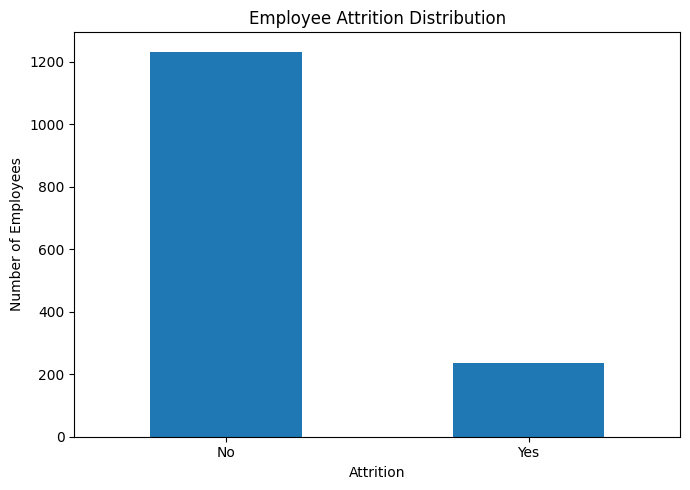

In [7]:
# ============================================================
# ATTRITION DISTRIBUTION CHART
# ============================================================

attrition_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Employees by Department:


,Employee Count
Research & Development,961
Sales,446
Human Resources,63


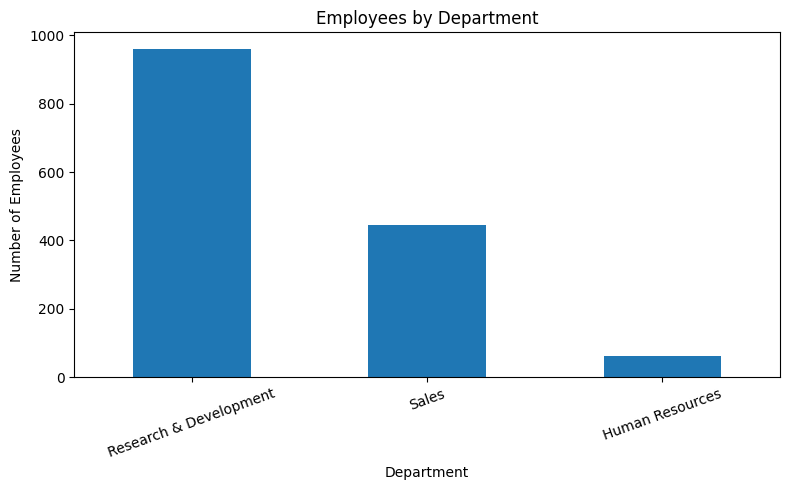

In [8]:
# ============================================================
# DEPARTMENT-WISE EMPLOYEE DISTRIBUTION
# ============================================================

department_counts = (
    employee_df["Department"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Employees by Department:")
display(
    department_counts.to_frame(
        name="Employee Count"
    )
)

department_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# DEPARTMENT-WISE ATTRITION ANALYSIS
# ============================================================

department_attrition = (
    employee_df
    .assign(
        Attrition_Flag=(
            employee_df["Attrition"]
            .eq("Yes")
            .astype(int)
        )
    )
    .groupby("Department")
    .agg(
        Total_Employees=("Attrition_Flag", "size"),
        Employees_Left=("Attrition_Flag", "sum"),
        Attrition_Rate=("Attrition_Flag", "mean")
    )
    .reset_index()
)

department_attrition["Attrition_Rate"] = (
    department_attrition["Attrition_Rate"] * 100
).round(2)

department_attrition = department_attrition.sort_values(
    by="Attrition_Rate",
    ascending=False
)

display(department_attrition)

,Department,Total_Employees,Employees_Left,Attrition_Rate
2,Sales,446,92,20.63
0,Human Resources,63,12,19.05
1,Research & Development,961,133,13.84


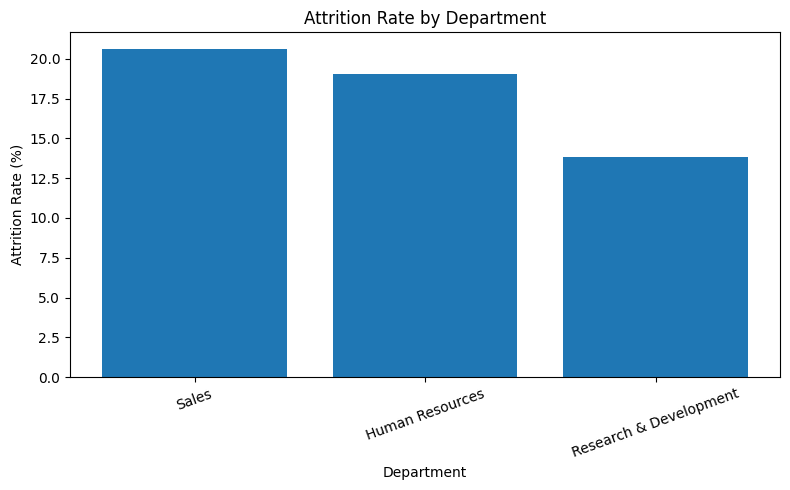

In [10]:
# ============================================================
# ATTRITION RATE BY DEPARTMENT
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    department_attrition["Department"],
    department_attrition["Attrition_Rate"]
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Age Statistics:


,Age
count,1470.000000
mean,36.923810
std,9.135373
min,18.000000
25%,30.000000
50%,36.000000
75%,43.000000
max,60.000000


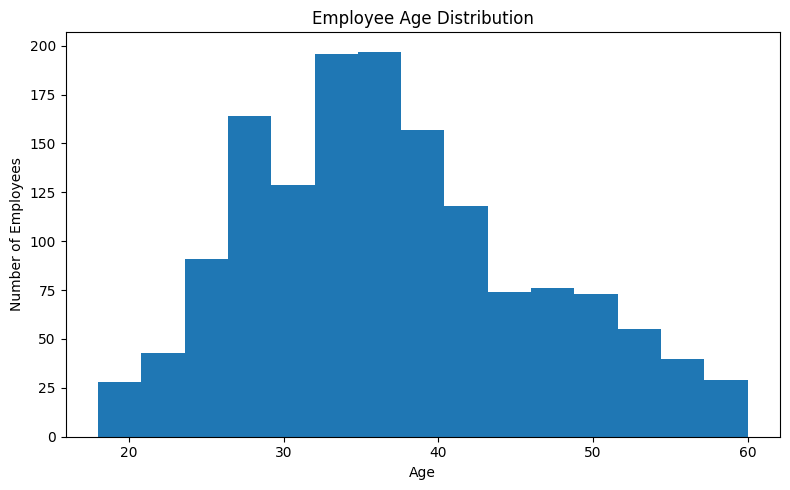

In [11]:
# ============================================================
# EMPLOYEE AGE DISTRIBUTION
# ============================================================

print("Age Statistics:")
display(
    employee_df["Age"]
    .describe()
    .to_frame(name="Age")
)

plt.figure(figsize=(8, 5))

plt.hist(
    employee_df["Age"],
    bins=15
)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [12]:
# ================================================================
# MONTHLY INCOME ANALYSIS
# ================================================================

income_stats = employee_df["MonthlyIncome"].describe()

print("MONTHLY INCOME STATISTICS")
print("=" * 50)

display(income_stats.to_frame(name="Monthly Income"))

MONTHLY INCOME STATISTICS


,Monthly Income
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


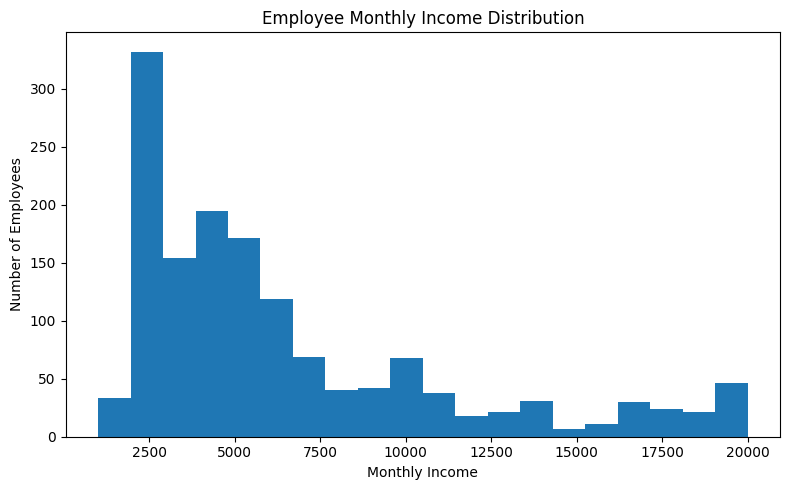

In [13]:
# ================================================================
# MONTHLY INCOME DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    employee_df["MonthlyIncome"],
    bins=20
)

plt.title("Employee Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [14]:
# ================================================================
# AVERAGE MONTHLY INCOME BY DEPARTMENT
# ================================================================

department_income = (
    employee_df
    .groupby("Department")["MonthlyIncome"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("AVERAGE MONTHLY INCOME BY DEPARTMENT")
display(department_income.to_frame(name="Average Monthly Income"))

AVERAGE MONTHLY INCOME BY DEPARTMENT


,Average Monthly Income
Department,
Sales,6959.17
Human Resources,6654.51
Research & Development,6281.25


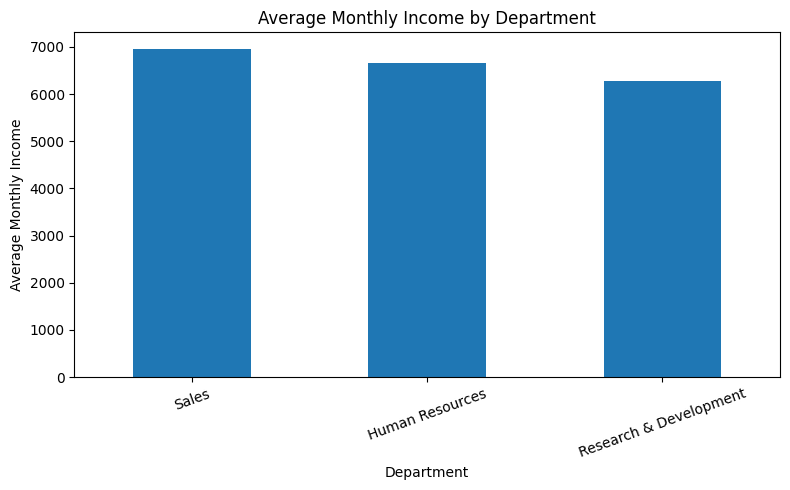

In [15]:
# ================================================================
# AVERAGE INCOME BY DEPARTMENT CHART
# ================================================================

department_income.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Monthly Income by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [16]:
# ================================================================
# AGE GROUP ANALYSIS
# ================================================================

age_analysis_df = employee_df.copy()

age_bins = [17, 25, 35, 45, 55, 65]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

age_analysis_df["Age Group"] = pd.cut(
    age_analysis_df["Age"],
    bins=age_bins,
    labels=age_labels
)

age_group_counts = age_analysis_df["Age Group"].value_counts().sort_index()

print("EMPLOYEES BY AGE GROUP")
display(age_group_counts.to_frame(name="Employee Count"))

EMPLOYEES BY AGE GROUP


,Employee Count
18-25,123
26-35,606
36-45,468
46-55,226
56-65,47


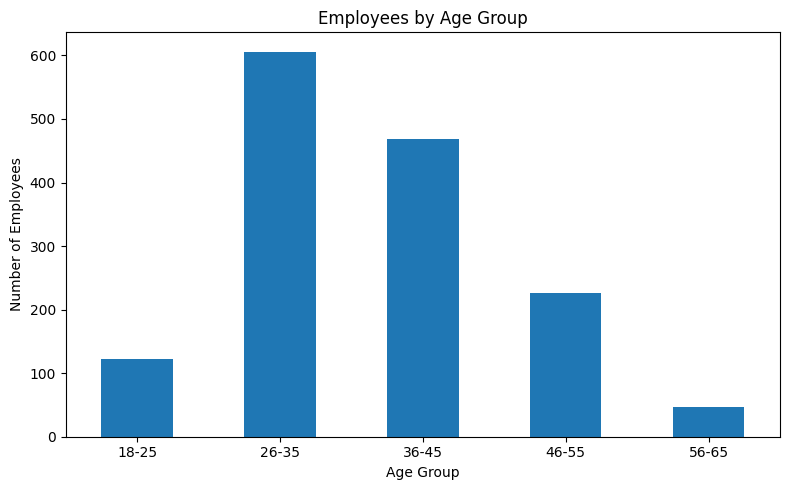

In [17]:
# ================================================================
# AGE GROUP DISTRIBUTION CHART
# ================================================================

age_group_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employees by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [18]:
# ================================================================
# ATTRITION RATE BY AGE GROUP
# ================================================================

age_group_attrition = (
    age_analysis_df
    .groupby("Age Group", observed=False)
    .agg(
        Total_Employees=("Attrition", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

age_group_attrition["Attrition Rate"] = (
    age_group_attrition["Employees_Left"]
    / age_group_attrition["Total_Employees"]
    * 100
).round(2)

print("ATTRITION RATE BY AGE GROUP")
display(age_group_attrition)

ATTRITION RATE BY AGE GROUP


,Age Group,Total_Employees,Employees_Left,Attrition Rate
0,18-25,123,44,35.77
1,26-35,606,116,19.14
2,36-45,468,43,9.19
3,46-55,226,26,11.50
4,56-65,47,8,17.02


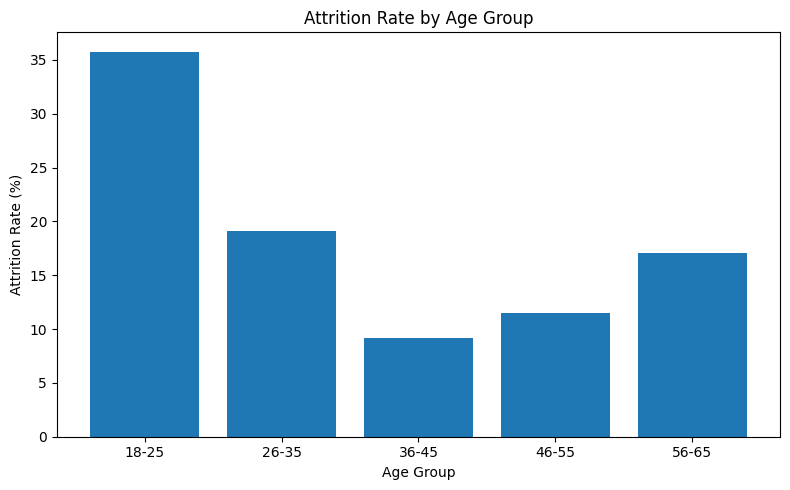

In [19]:
# ================================================================
# AGE GROUP ATTRITION RATE CHART
# ================================================================

plt.figure(figsize=(8, 5))

plt.bar(
    age_group_attrition["Age Group"].astype(str),
    age_group_attrition["Attrition Rate"]
)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

In [20]:
# ================================================================
# JOB ROLE ANALYSIS
# ================================================================

job_role_counts = employee_df["JobRole"].value_counts()

print("EMPLOYEES BY JOB ROLE")
print("=" * 60)

display(job_role_counts.to_frame(name="Employee Count"))

EMPLOYEES BY JOB ROLE


,Employee Count
Sales Executive,326
Research Scientist,292
Laboratory Technician,259
Manufacturing Director,145
Healthcare Representative,131
Manager,102
Sales Representative,83
Research Director,80
Human Resources,52


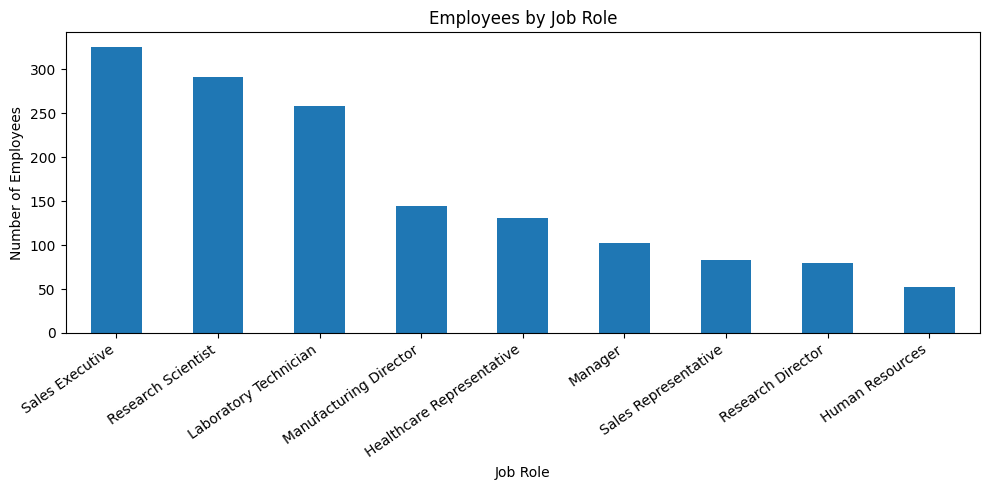

In [21]:
# ================================================================
# JOB ROLE DISTRIBUTION CHART
# ================================================================

job_role_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Employees by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [23]:
# ================================================================
# ATTRITION RATE BY JOB ROLE
# ================================================================

job_role_attrition = (
    employee_df
    .groupby("JobRole")
    .agg(
        Total_Employees=("Attrition", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

job_role_attrition["Attrition Rate"] = (
    job_role_attrition["Employees_Left"]
    / job_role_attrition["Total_Employees"]
    * 100
).round(2)

job_role_attrition = job_role_attrition.sort_values(
    by="Attrition Rate",
    ascending=False
)

print("ATTRITION RATE BY JOB ROLE")
display(job_role_attrition)

ATTRITION RATE BY JOB ROLE


,JobRole,Total_Employees,Employees_Left,Attrition Rate
8,Sales Representative,83,33,39.76
2,Laboratory Technician,259,62,23.94
1,Human Resources,52,12,23.08
7,Sales Executive,326,57,17.48
6,Research Scientist,292,47,16.10
4,Manufacturing Director,145,10,6.90
0,Healthcare Representative,131,9,6.87
3,Manager,102,5,4.90
5,Research Director,80,2,2.50


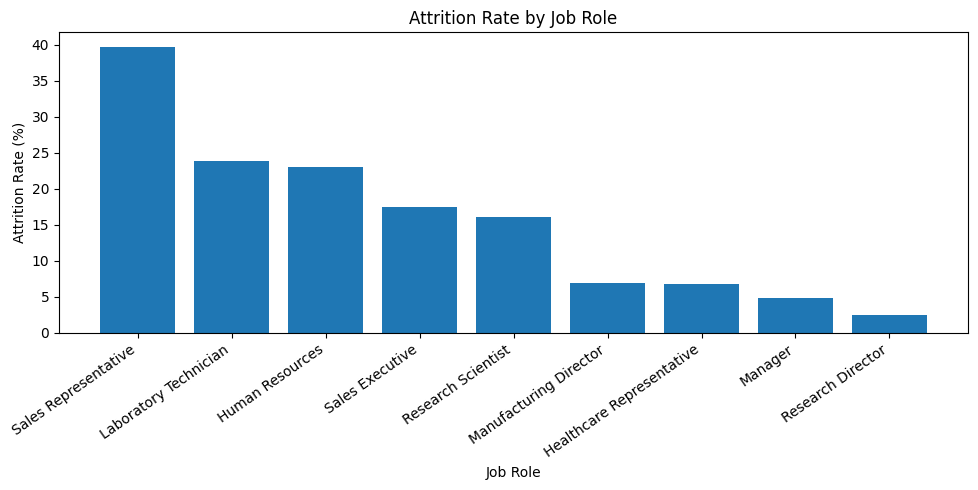

In [24]:
# ================================================================
# ATTRITION RATE BY JOB ROLE CHART
# ================================================================

plt.figure(figsize=(10, 5))

plt.bar(
    job_role_attrition["JobRole"],
    job_role_attrition["Attrition Rate"]
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [25]:
# ================================================================
# MONTHLY INCOME ANALYSIS
# ================================================================

income_stats = employee_df["MonthlyIncome"].describe()

print("MONTHLY INCOME STATISTICS")
print("=" * 50)

display(
    income_stats.to_frame(
        name="Monthly Income"
    )
)

MONTHLY INCOME STATISTICS


,Monthly Income
count,1470.000000
mean,6502.931293
std,4707.956783
min,1009.000000
25%,2911.000000
50%,4919.000000
75%,8379.000000
max,19999.000000


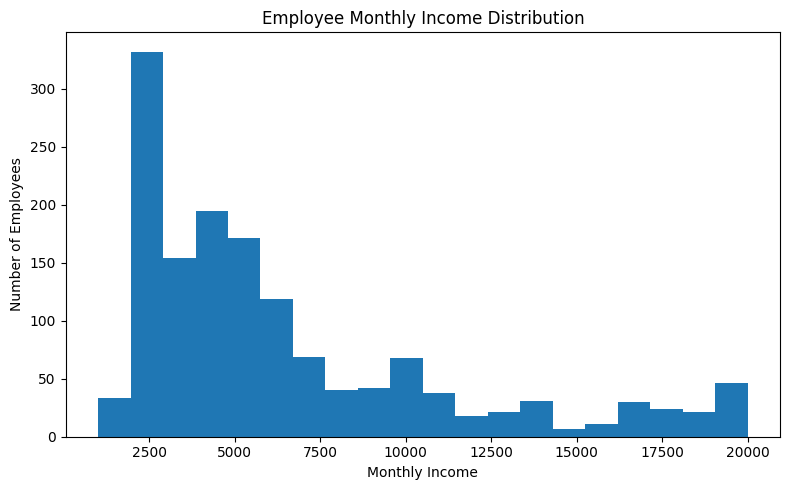

In [26]:
# ================================================================
# MONTHLY INCOME DISTRIBUTION CHART
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    employee_df["MonthlyIncome"],
    bins=20
)

plt.title("Employee Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


In [27]:
# ================================================================
# AVERAGE MONTHLY INCOME BY DEPARTMENT
# ================================================================

department_income = (
    employee_df
    .groupby("Department")["MonthlyIncome"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("AVERAGE MONTHLY INCOME BY DEPARTMENT")

display(
    department_income.to_frame(
        name="Average Monthly Income"
    )
)

AVERAGE MONTHLY INCOME BY DEPARTMENT


,Average Monthly Income
Department,
Sales,6959.17
Human Resources,6654.51
Research & Development,6281.25


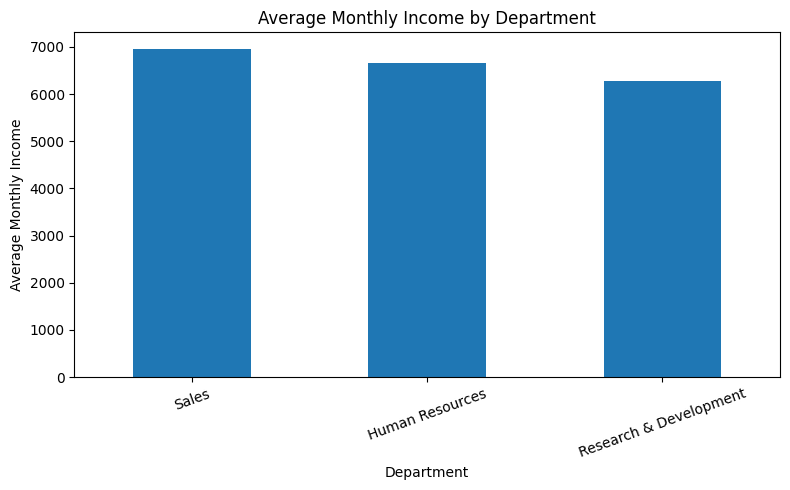

In [28]:
# ================================================================
# AVERAGE INCOME BY DEPARTMENT CHART
# ================================================================

department_income.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Monthly Income by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [29]:
# ================================================================
# INCOME BY ATTRITION STATUS
# ================================================================

income_by_attrition = (
    employee_df
    .groupby("Attrition")["MonthlyIncome"]
    .mean()
    .round(2)
)

print("AVERAGE MONTHLY INCOME BY ATTRITION STATUS")

display(
    income_by_attrition.to_frame(
        name="Average Monthly Income"
    )
)

AVERAGE MONTHLY INCOME BY ATTRITION STATUS


,Average Monthly Income
Attrition,
No,6832.74
Yes,4787.09


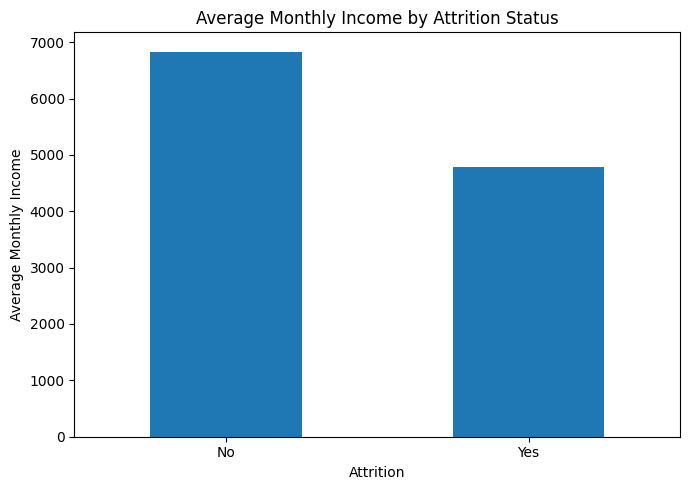

In [30]:
# ================================================================
# INCOME BY ATTRITION STATUS CHART
# ================================================================

income_by_attrition.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Income by Attrition Status")
plt.xlabel("Attrition")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [31]:
# ================================================================
# OVERTIME ANALYSIS
# ================================================================

overtime_counts = employee_df["OverTime"].value_counts()

print("EMPLOYEES WORKING OVERTIME")

display(
    overtime_counts.to_frame(
        name="Employee Count"
    )
)

EMPLOYEES WORKING OVERTIME


,Employee Count
No,1054
Yes,416


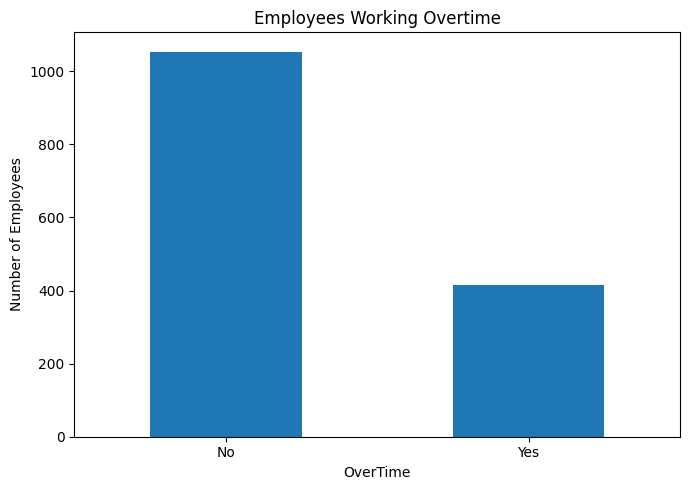

In [32]:
# ================================================================
# OVERTIME DISTRIBUTION CHART
# ================================================================

overtime_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Employees Working Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [33]:
# ================================================================
# ATTRITION RATE BY OVERTIME
# ================================================================

overtime_attrition = (
    employee_df
    .groupby("OverTime")
    .agg(
        Total_Employees=("Attrition", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

overtime_attrition["Attrition Rate"] = (
    overtime_attrition["Employees_Left"]
    / overtime_attrition["Total_Employees"]
    * 100
).round(2)

print("ATTRITION RATE BY OVERTIME")

display(overtime_attrition)

ATTRITION RATE BY OVERTIME


,OverTime,Total_Employees,Employees_Left,Attrition Rate
0,No,1054,110,10.44
1,Yes,416,127,30.53


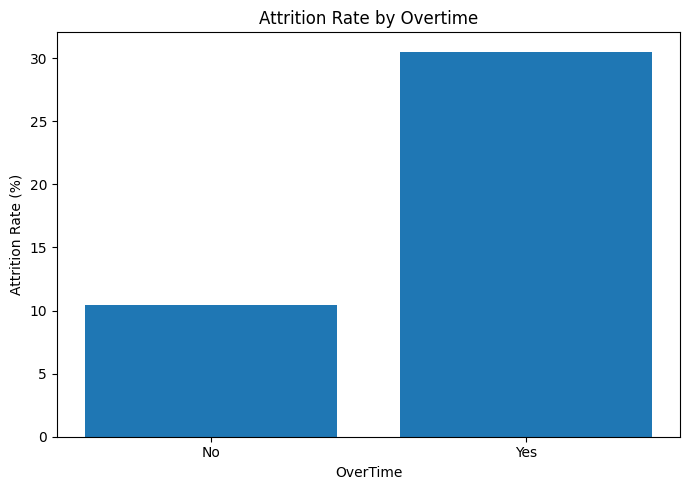

In [34]:
# ================================================================
# ATTRITION RATE BY OVERTIME CHART
# ================================================================

plt.figure(figsize=(7, 5))

plt.bar(
    overtime_attrition["OverTime"],
    overtime_attrition["Attrition Rate"]
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

In [35]:
# ================================================================
# JOB SATISFACTION ANALYSIS
# ================================================================

job_satisfaction_counts = (
    employee_df["JobSatisfaction"]
    .value_counts()
    .sort_index()
)

print("JOB SATISFACTION DISTRIBUTION")

display(
    job_satisfaction_counts.to_frame(
        name="Employee Count"
    )
)


JOB SATISFACTION DISTRIBUTION


,Employee Count
1,289
2,280
3,442
4,459


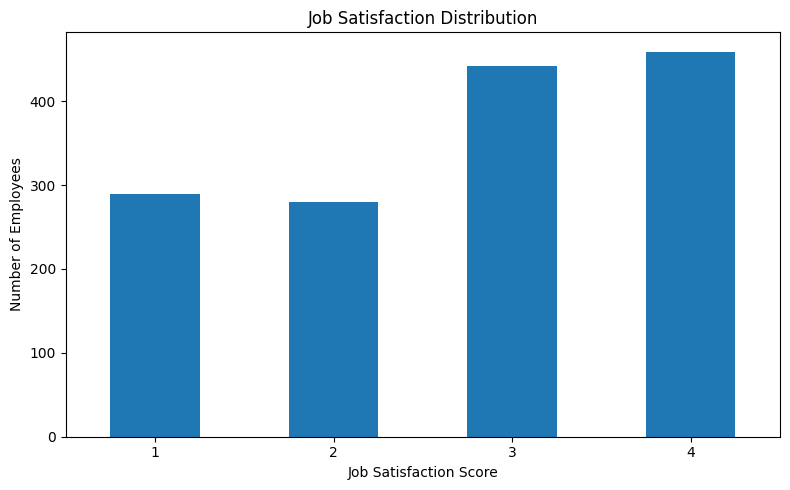

In [36]:
# ================================================================
# JOB SATISFACTION DISTRIBUTION CHART
# ================================================================

job_satisfaction_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Job Satisfaction Distribution")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [37]:
# ================================================================
# ATTRITION RATE BY JOB SATISFACTION
# ================================================================

satisfaction_attrition = (
    employee_df
    .groupby("JobSatisfaction")
    .agg(
        Total_Employees=("Attrition", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

satisfaction_attrition["Attrition Rate"] = (
    satisfaction_attrition["Employees_Left"]
    / satisfaction_attrition["Total_Employees"]
    * 100
).round(2)

print("ATTRITION RATE BY JOB SATISFACTION")

display(satisfaction_attrition)

ATTRITION RATE BY JOB SATISFACTION


,JobSatisfaction,Total_Employees,Employees_Left,Attrition Rate
0,1,289,66,22.84
1,2,280,46,16.43
2,3,442,73,16.52
3,4,459,52,11.33


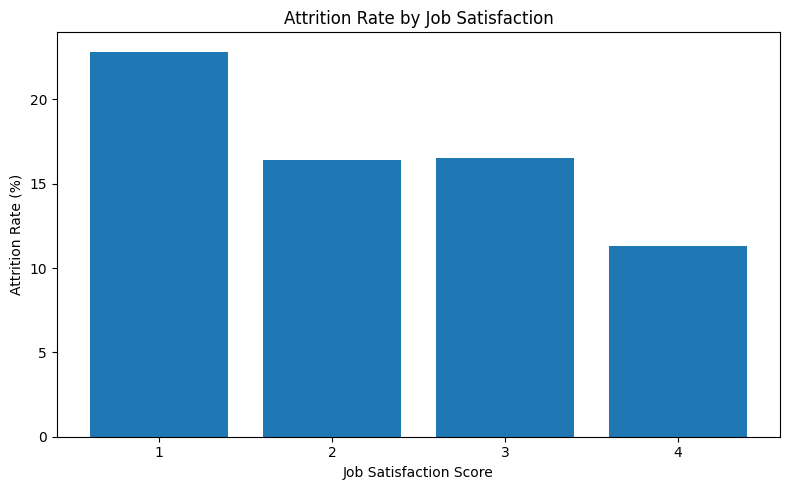

In [38]:
# ================================================================
# ATTRITION RATE BY JOB SATISFACTION CHART
# ================================================================

plt.figure(figsize=(8, 5))

plt.bar(
    satisfaction_attrition["JobSatisfaction"].astype(str),
    satisfaction_attrition["Attrition Rate"]
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

In [39]:
# ================================================================
# YEARS AT COMPANY ANALYSIS
# ================================================================

years_stats = employee_df["YearsAtCompany"].describe()

print("YEARS AT COMPANY STATISTICS")

display(
    years_stats.to_frame(
        name="Years At Company"
    )
)

YEARS AT COMPANY STATISTICS


,Years At Company
count,1470.000000
mean,7.008163
std,6.126525
min,0.000000
25%,3.000000
50%,5.000000
75%,9.000000
max,40.000000


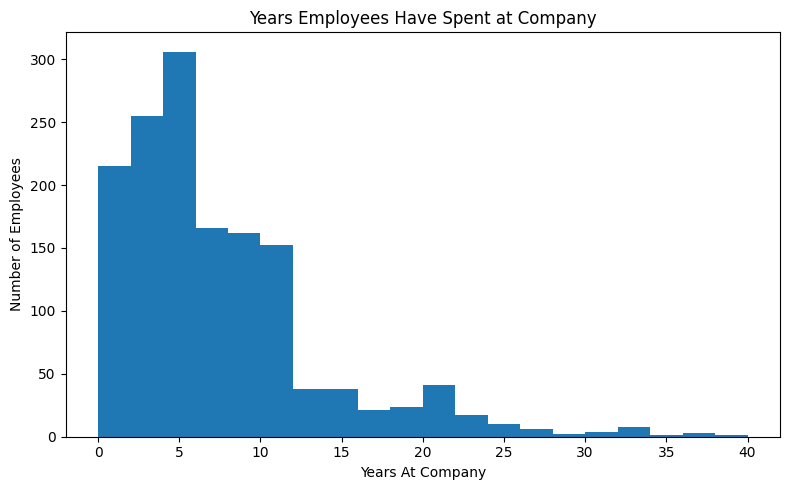

In [40]:
# ================================================================
# YEARS AT COMPANY DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    employee_df["YearsAtCompany"],
    bins=20
)

plt.title("Years Employees Have Spent at Company")
plt.xlabel("Years At Company")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()


In [41]:
# ================================================================
# ATTRITION BY YEARS AT COMPANY
# ================================================================

company_year_attrition = (
    employee_df
    .groupby("YearsAtCompany")
    .agg(
        Total_Employees=("Attrition", "count"),
        Employees_Left=("Attrition", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

company_year_attrition["Attrition Rate"] = (
    company_year_attrition["Employees_Left"]
    / company_year_attrition["Total_Employees"]
    * 100
).round(2)

display(company_year_attrition)

,YearsAtCompany,Total_Employees,Employees_Left,Attrition Rate
0,0,44,16,36.36
1,1,171,59,34.50
2,2,127,27,21.26
3,3,128,20,15.62
4,4,110,19,17.27
5,5,196,21,10.71
6,6,76,9,11.84
7,7,90,11,12.22
8,8,80,9,11.25
9,9,82,8,9.76


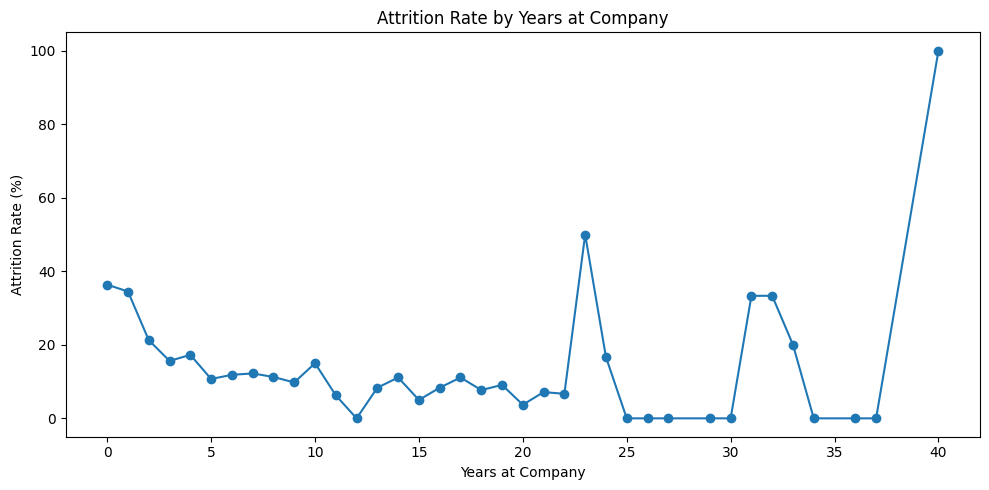

In [42]:
# ================================================================
# ATTRITION RATE BY YEARS AT COMPANY CHART
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    company_year_attrition["YearsAtCompany"],
    company_year_attrition["Attrition Rate"],
    marker="o"
)

plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

In [43]:
# ================================================================
# PERFORMANCE AND ENGAGEMENT OVERVIEW
# ================================================================

print("PERFORMANCE AND ENGAGEMENT DATASET")
print("=" * 60)

print(f"Total Records: {len(performance_df)}")
print(f"Total Columns: {performance_df.shape[1]}")

print("\nDATA TYPES:")
display(performance_df.dtypes.to_frame(name="Data Type"))

PERFORMANCE AND ENGAGEMENT DATASET
Total Records: 5000
Total Columns: 13

DATA TYPES:


,Data Type
Employee ID,int64
Name,object
Department,object
Job Role,object
Performance Score,int64
KPI Score,float64
Attendance (%),float64
Peer Rating,float64
Task Completion (%),float64
Work Hours Logged,int64


In [44]:
# ================================================================
# PERFORMANCE SCORE ANALYSIS
# ================================================================

performance_score_stats = (
    performance_df["Performance Score"]
    .describe()
)

print("PERFORMANCE SCORE STATISTICS")

display(
    performance_score_stats.to_frame(
        name="Performance Score"
    )
)

PERFORMANCE SCORE STATISTICS


,Performance Score
count,5000.000000
mean,74.779400
std,14.666211
min,50.000000
25%,62.000000
50%,75.000000
75%,87.000000
max,100.000000


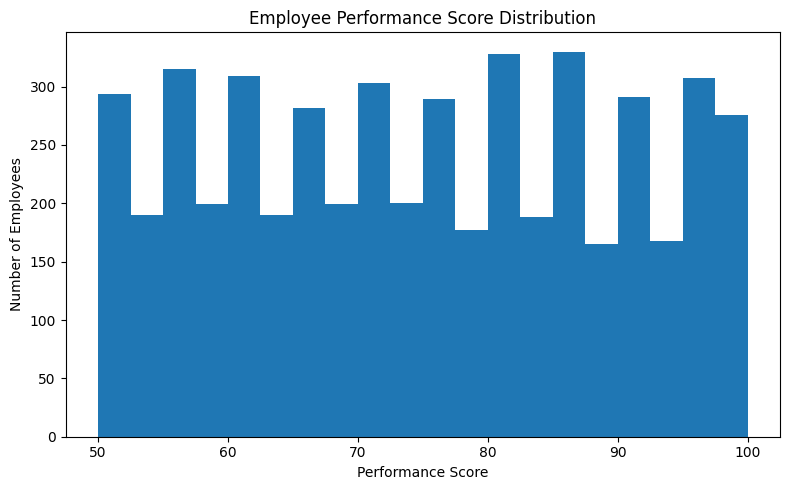

In [45]:
# ================================================================
# PERFORMANCE SCORE DISTRIBUTION
# ================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    performance_df["Performance Score"],
    bins=20
)

plt.title("Employee Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")

plt.tight_layout()
plt.show()

In [46]:
# ================================================================
# AVERAGE PERFORMANCE BY DEPARTMENT
# ================================================================

department_performance = (
    performance_df
    .groupby("Department")["Performance Score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("AVERAGE PERFORMANCE SCORE BY DEPARTMENT")

display(
    department_performance.to_frame(
        name="Average Performance Score"
    )
)

AVERAGE PERFORMANCE SCORE BY DEPARTMENT


,Average Performance Score
Department,
HR,75.83
Finance,75.16
IT,74.68
Sales,74.34
Marketing,73.86


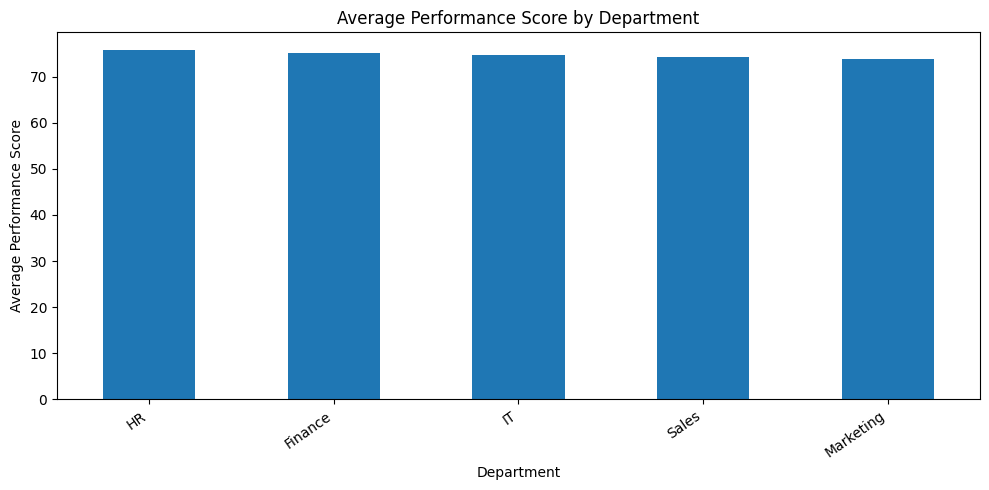

In [47]:
# ================================================================
# AVERAGE PERFORMANCE BY DEPARTMENT CHART
# ================================================================

department_performance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Performance Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [48]:
# ================================================================
# KPI SCORE ANALYSIS
# ================================================================

kpi_stats = performance_df["KPI Score"].describe()

print("KPI SCORE STATISTICS")

display(
    kpi_stats.to_frame(
        name="KPI Score"
    )
)

KPI SCORE STATISTICS


,KPI Score
count,5000.000000
mean,77.384996
std,10.157152
min,60.010000
25%,68.327500
50%,77.340000
75%,86.050000
max,94.990000


In [49]:
# ================================================================
# ATTENDANCE ANALYSIS
# ================================================================

attendance_stats = performance_df["Attendance (%)"].describe()

print("ATTENDANCE STATISTICS")

display(
    attendance_stats.to_frame(
        name="Attendance (%)"
    )
)

ATTENDANCE STATISTICS


,Attendance (%)
count,5000.000000
mean,87.466720
std,7.230827
min,75.010000
25%,81.130000
50%,87.415000
75%,93.752500
max,100.000000


In [50]:
# ================================================================
# AVERAGE ATTENDANCE BY DEPARTMENT
# ================================================================

department_attendance = (
    performance_df
    .groupby("Department")["Attendance (%)"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("AVERAGE ATTENDANCE BY DEPARTMENT")

display(
    department_attendance.to_frame(
        name="Average Attendance (%)"
    )
)

AVERAGE ATTENDANCE BY DEPARTMENT


,Average Attendance (%)
Department,
IT,87.66
Sales,87.58
Finance,87.55
HR,87.27
Marketing,87.26


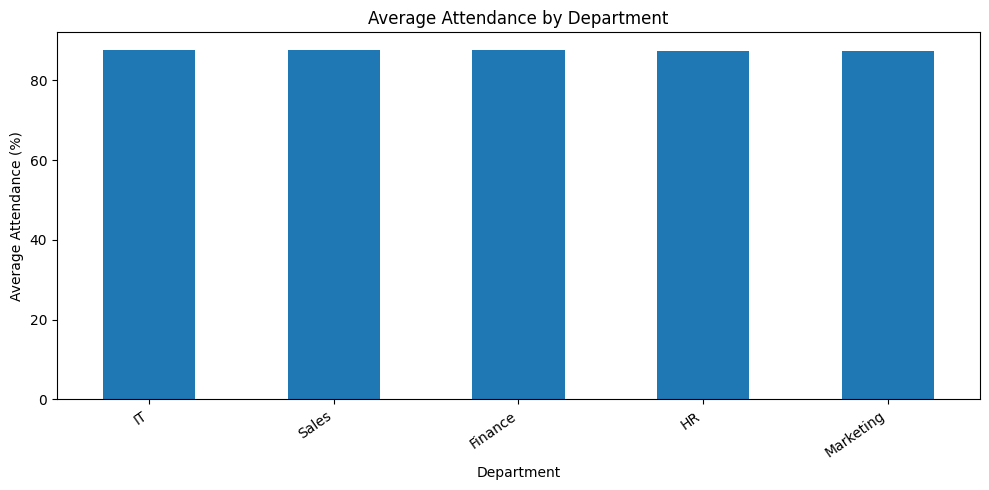

In [51]:
# ================================================================
# ATTENDANCE BY DEPARTMENT CHART
# ================================================================

department_attendance.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Attendance by Department")
plt.xlabel("Department")
plt.ylabel("Average Attendance (%)")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

In [52]:
# ================================================================
# TRAINING HOURS ANALYSIS
# ================================================================

training_stats = performance_df["Training Hours"].describe()

print("TRAINING HOURS STATISTICS")

display(
    training_stats.to_frame(
        name="Training Hours"
    )
)

TRAINING HOURS STATISTICS


,Training Hours
count,5000.000000
mean,14.876800
std,9.005523
min,0.000000
25%,7.000000
50%,15.000000
75%,23.000000
max,30.000000


In [53]:
# ================================================================
# PROMOTION ELIGIBILITY ANALYSIS
# ================================================================

promotion_counts = (
    performance_df["Promotion Eligibility"]
    .value_counts()
)

print("PROMOTION ELIGIBILITY DISTRIBUTION")

display(
    promotion_counts.to_frame(
        name="Employee Count"
    )
)

PROMOTION ELIGIBILITY DISTRIBUTION


,Employee Count
No,4305
Yes,695


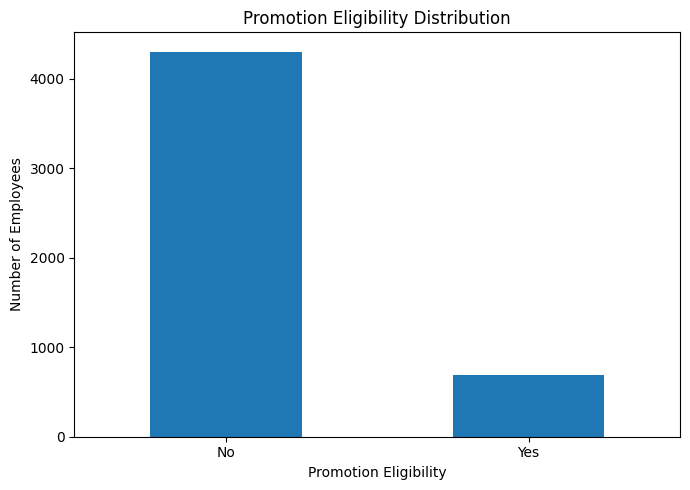

In [54]:
# ================================================================
# PROMOTION ELIGIBILITY CHART
# ================================================================

promotion_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Promotion Eligibility Distribution")
plt.xlabel("Promotion Eligibility")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [55]:
# ================================================================
# NUMERICAL CORRELATION ANALYSIS
# ================================================================

numeric_columns = [
    "Age",
    "DailyRate",
    "HourlyRate",
    "MonthlyIncome",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

correlation_matrix = employee_df[numeric_columns].corr()

print("EMPLOYEE DATA CORRELATION MATRIX")

display(correlation_matrix.round(2))

EMPLOYEE DATA CORRELATION MATRIX


,Age,DailyRate,HourlyRate,MonthlyIncome,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,0.01,0.02,0.50,0.00,0.68,0.31,0.21,0.22,0.20
DailyRate,0.01,1.00,0.02,0.01,0.02,0.01,-0.03,0.01,-0.03,-0.03
HourlyRate,0.02,0.02,1.00,-0.02,-0.01,-0.00,-0.02,-0.02,-0.03,-0.02
MonthlyIncome,0.50,0.01,-0.02,1.00,-0.03,0.77,0.51,0.36,0.34,0.34
PercentSalaryHike,0.00,0.02,-0.01,-0.03,1.00,-0.02,-0.04,-0.00,-0.02,-0.01
TotalWorkingYears,0.68,0.01,-0.00,0.77,-0.02,1.00,0.63,0.46,0.40,0.46
YearsAtCompany,0.31,-0.03,-0.02,0.51,-0.04,0.63,1.00,0.76,0.62,0.77
YearsInCurrentRole,0.21,0.01,-0.02,0.36,-0.00,0.46,0.76,1.00,0.55,0.71
YearsSinceLastPromotion,0.22,-0.03,-0.03,0.34,-0.02,0.40,0.62,0.55,1.00,0.51
YearsWithCurrManager,0.20,-0.03,-0.02,0.34,-0.01,0.46,0.77,0.71,0.51,1.00


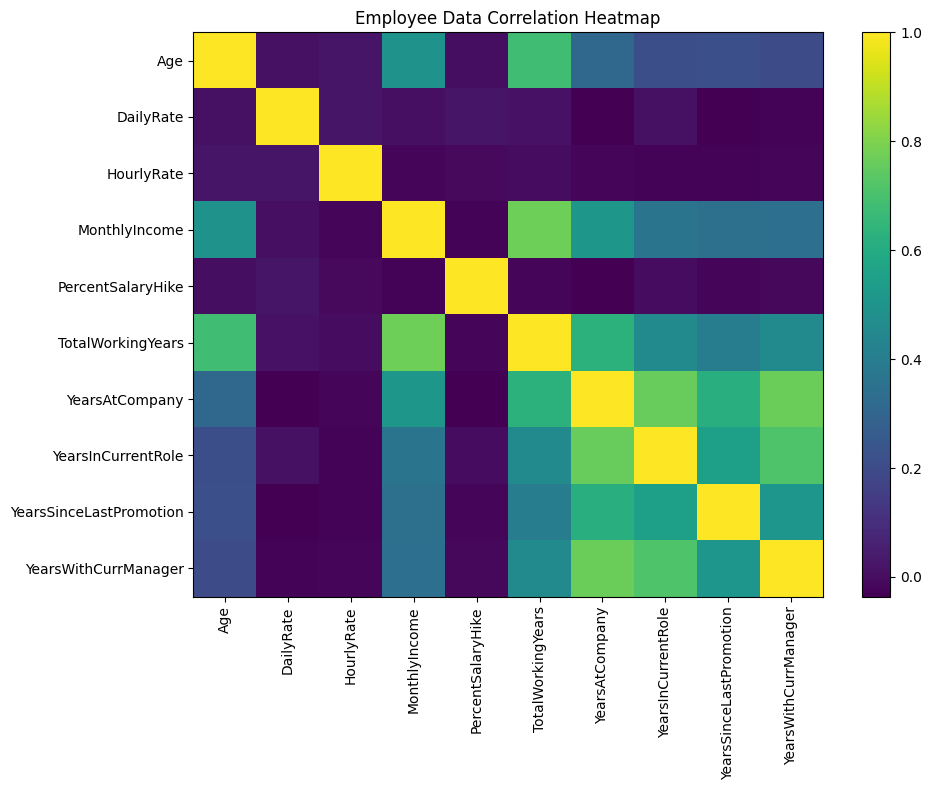

In [56]:
# ================================================================
# CORRELATION HEATMAP
# ================================================================

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Employee Data Correlation Heatmap")

plt.tight_layout()
plt.show()

In [57]:
# ================================================================
# EXPLORATORY DATA ANALYSIS SUMMARY
# ================================================================

eda_summary = {
    "Total Employees": len(employee_df),
    
    "Employees Retained": int(
        (employee_df["Attrition"] == "No").sum()
    ),
    
    "Employees Left": int(
        (employee_df["Attrition"] == "Yes").sum()
    ),
    
    "Overall Attrition Rate (%)": round(
        (employee_df["Attrition"] == "Yes").mean() * 100,
        2
    ),
    
    "Average Age": round(
        employee_df["Age"].mean(),
        2
    ),
    
    "Average Monthly Income": round(
        employee_df["MonthlyIncome"].mean(),
        2
    ),
    
    "Average Years At Company": round(
        employee_df["YearsAtCompany"].mean(),
        2
    ),
    
    "Performance Dataset Records": len(
        performance_df
    ),
    
    "Average Performance Score": round(
        performance_df["Performance Score"].mean(),
        2
    ),
    
    "Average KPI Score": round(
        performance_df["KPI Score"].mean(),
        2
    ),
    
    "Average Attendance (%)": round(
        performance_df["Attendance (%)"].mean(),
        2
    )
}

eda_summary_df = pd.DataFrame(
    list(eda_summary.items()),
    columns=["Metric", "Value"]
)

print("FINAL EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

display(eda_summary_df)

FINAL EXPLORATORY DATA ANALYSIS SUMMARY


,Metric,Value
0,Total Employees,1470.00
1,Employees Retained,1233.00
2,Employees Left,237.00
3,Overall Attrition Rate (%),16.12
4,Average Age,36.92
5,Average Monthly Income,6502.93
6,Average Years At Company,7.01
7,Performance Dataset Records,5000.00
8,Average Performance Score,74.78
9,Average KPI Score,77.38
